# Monte Carlo v4 -- Analysis Scenarios (Super Gaussian)

`production_10k_s1` (Scenario 1) / `production_10k_s2` (Scenario 2), 10,000 trials each, `supergaussian` wake model.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 11

RESULTS = Path("../../results")
COLOR_S1 = "#2a78d6"   # Scenario 1 -- categorical slot 1
COLOR_S2 = "#eb6834"   # Scenario 2 -- categorical slot 2
COLOR_NEUTRAL = "#52514e"

In [2]:
def load_scenario(scenario, run_id):
    d = RESULTS / scenario / run_id / "merged"
    return (pd.read_parquet(d / "trials.parquet"),
            pd.read_parquet(d / "arrivals.parquet"),
            pd.read_parquet(d / "segments.parquet"))

trials_s1, arrivals_s1, segments_s1 = load_scenario("scenario_1", "production_10k_s1")
trials_s2, arrivals_s2, segments_s2 = load_scenario("scenario_2", "production_10k_s2")

In [3]:
# one row per trial, taken at the final 5-year checkpoint (lifetime/final state)
FINAL_SEGMENT = segments_s1["segment_id"].max()
FINAL_SEGMENT

np.int64(4)

In [4]:
def trial_density(arrivals):
    # mean rho_target across every farm that drew one (speculative, + cluster_fixed in Scenario 2)
    return arrivals.dropna(subset=["rho_target_mw_km2"]).groupby("trial_id")["rho_target_mw_km2"].mean().rename("mean_density_mw_km2")

final_s1 = segments_s1[segments_s1.segment_id == FINAL_SEGMENT].merge(trials_s1, on="trial_id").merge(trial_density(arrivals_s1), on="trial_id", how="left")
final_s2 = segments_s2[segments_s2.segment_id == FINAL_SEGMENT].merge(trials_s2, on="trial_id").merge(trial_density(arrivals_s2), on="trial_id", how="left")
final_s1.shape, final_s2.shape

((10000, 28), (10000, 28))

### Plot helpers

In [5]:
def hist_with_percentiles(data, color, xlabel, ylabel, title, bins=40, qs=(10, 50, 90)):
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    ax.hist(data, bins=bins, color=color, alpha=0.85, edgecolor="white", linewidth=0.3)
    ymax = ax.get_ylim()[1]
    for q in qs:
        v = np.percentile(data, q)
        ax.axvline(v, color=COLOR_NEUTRAL, linestyle="--", linewidth=1)
        ax.text(v, ymax, f"P{q}", rotation=90, va="top", ha="right", fontsize=8, color=COLOR_NEUTRAL)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    fig.tight_layout()
    return fig, ax

def percentile_band_plot(data, color, xlabel, title, qs=(10, 50, 90)):
    vals = np.percentile(data, qs)
    fig, ax = plt.subplots(figsize=(6.5, 1.8))
    ax.plot(vals, [0, 0, 0], color=color, linewidth=2, zorder=1)
    ax.scatter(vals, [0, 0, 0], color=color, s=60, zorder=2)
    for q, v in zip(qs, vals):
        ax.annotate(f"P{q}: {v:,.1f}", (v, 0), textcoords="offset points", xytext=(0, 12),
                    ha="center", fontsize=9, color=COLOR_NEUTRAL)
    ax.set_yticks([]); ax.set_xlabel(xlabel); ax.set_title(title)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.set_ylim(-1, 1)
    fig.tight_layout()
    return fig, ax

def segment_trajectory(segments, color, ylabel, title, value_col="loss_pct"):
    grouped = segments.groupby("start_year")[value_col]
    p10, p50, p90 = grouped.quantile(0.10), grouped.quantile(0.50), grouped.quantile(0.90)
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    ax.fill_between(p50.index, p10, p90, color=color, alpha=0.2, label="P10-P90")
    ax.plot(p50.index, p50, color=color, linewidth=2, marker="o", label="P50")
    ax.set_xlabel("Simulation Year"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    return fig, ax

## Scenario 1 -- Real farms + isolated self

### Phase 1 -- Data Audit

In [6]:
trials_s1.shape, arrivals_s1.shape, segments_s1.shape

((10000, 13), (222434, 9), (50000, 15))

In [7]:
trials_s1.isna().sum().sum(), arrivals_s1.isna().sum().sum(), segments_s1.isna().sum().sum()

(np.int64(0), np.int64(140000), np.int64(0))

In [8]:
trials_s1.trial_id.nunique(), segments_s1.trial_id.nunique()  # integrity: every trial reached the final segment

(10000, 10000)

### Input Uncertainty

In [9]:
trials_s1[['climate_rotation_deg', 'climate_speed_multiplier', 'climate_spread_multiplier']].describe()

,climate_rotation_deg,climate_speed_multiplier,climate_spread_multiplier
count,10000.000000,10000.000000,10000.000000
mean,0.004905,1.000005,1.000182
std,1.451754,0.004794,0.025552
min,-3.935272,0.990664,0.941646
25%,-0.967548,0.996565,0.982683
50%,0.009613,1.000019,0.999843
75%,0.998158,1.003367,1.017706
max,3.935272,1.010155,1.070733


In [10]:
final_s1['mean_density_mw_km2'].describe()

count    10000.000000
mean         5.044288
std          0.355881
min          3.871925
25%          4.792734
50%          5.022666
75%          5.276898
max          6.520006
Name: mean_density_mw_km2, dtype: float64

In [11]:
final_s1['n_speculative'].describe()

count    10000.000000
mean        17.243400
std          3.144987
min          7.000000
25%         15.000000
50%         17.000000
75%         19.000000
max         30.000000
Name: n_speculative, dtype: float64

### Correlation vs Outputs

In [12]:
predictors = ["climate_rotation_deg", "climate_speed_multiplier", "climate_spread_multiplier",
              "n_speculative", "mean_density_mw_km2", "active_mw", "n_active_turbines"]
targets = ["active_aep_gwh", "loss_pct"]

pearson_s1 = final_s1[predictors + targets].corr(method="pearson").loc[predictors, targets]
pearson_s1

,active_aep_gwh,loss_pct
climate_rotation_deg,0.032470,0.023908
climate_speed_multiplier,0.386370,-0.017092
climate_spread_multiplier,0.056959,-0.012094
n_speculative,-0.068187,0.075362
mean_density_mw_km2,0.027313,-0.026906
active_mw,-0.332289,0.366567
n_active_turbines,-0.316039,0.351405


In [13]:
spearman_s1 = final_s1[predictors + targets].corr(method="spearman").loc[predictors, targets]
spearman_s1

,active_aep_gwh,loss_pct
climate_rotation_deg,0.040357,0.021025
climate_speed_multiplier,0.419295,-0.012523
climate_spread_multiplier,0.060515,-0.013331
n_speculative,-0.078114,0.093432
mean_density_mw_km2,0.036924,-0.040624
active_mw,-0.341014,0.402208
n_active_turbines,-0.326131,0.386983


In [14]:
pearson_s1['loss_pct'].sort_values(key=abs, ascending=False)  # ranked drivers of Wake Loss

active_mw                    0.366567
n_active_turbines            0.351405
n_speculative                0.075362
mean_density_mw_km2         -0.026906
climate_rotation_deg         0.023908
climate_speed_multiplier    -0.017092
climate_spread_multiplier   -0.012094
Name: loss_pct, dtype: float64

### Phase 2 -- Exploratory Visualizations

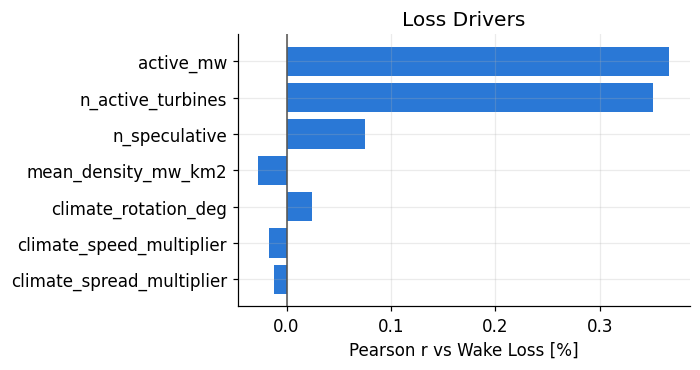

In [15]:
drivers = pearson_s1["loss_pct"].sort_values(key=abs)
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.barh(drivers.index, drivers.values, color=COLOR_S1)
ax.axvline(0, color=COLOR_NEUTRAL, linewidth=1)
ax.set_xlabel("Pearson r vs Wake Loss [%]"); ax.set_title("Loss Drivers")
fig.tight_layout()

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Turbine Density'}, xlabel='Turbine Density [MW/km²]', ylabel='Farms [count]'>)

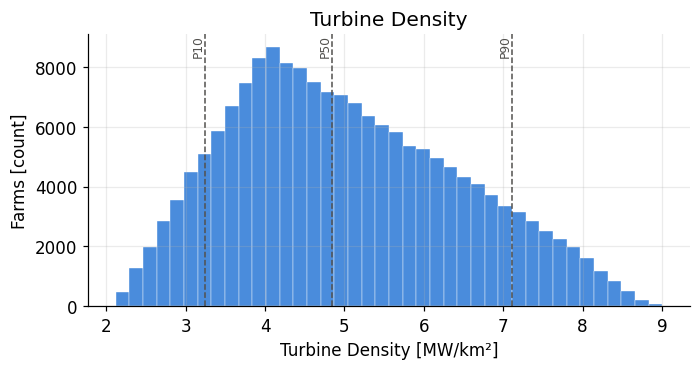

In [16]:
density = arrivals_s1["rho_target_mw_km2"].dropna()
hist_with_percentiles(density, COLOR_S1, "Turbine Density [MW/km\u00b2]", "Farms [count]", "Turbine Density")

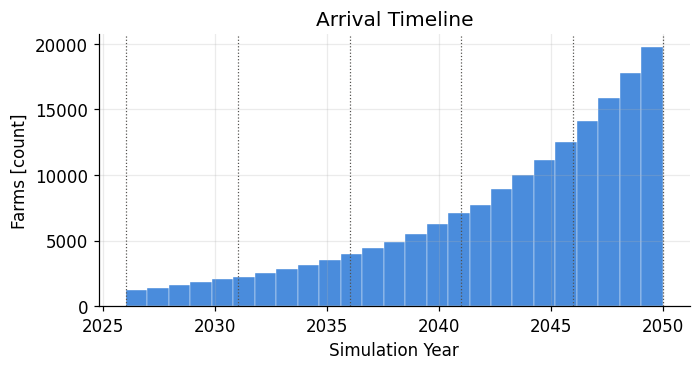

In [17]:
# only "speculative" farms draw a random arrival year -- self/real_layout/cluster_fixed are all fixed at YEAR_START
checkpoints = sorted(set(segments_s1.start_year) | set(segments_s1.end_year))
new_farm_years = arrivals_s1.loc[arrivals_s1.source == "speculative", "arrival_year"]
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(new_farm_years, bins=25, color=COLOR_S1, alpha=0.85, edgecolor="white", linewidth=0.3)
for yr in checkpoints:
    ax.axvline(yr, color=COLOR_NEUTRAL, linestyle=":", linewidth=0.8)
ax.set_xlabel("Simulation Year"); ax.set_ylabel("Farms [count]"); ax.set_title("Arrival Timeline")
fig.tight_layout()

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Turbine Scale'}, xlabel='Active Turbines [count]', ylabel='Trials (Samples)'>)

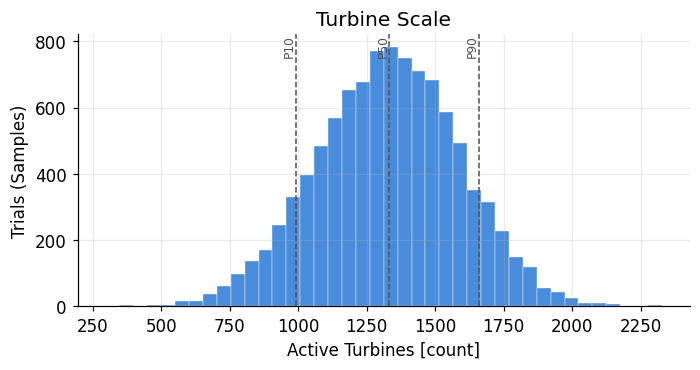

In [18]:
hist_with_percentiles(final_s1["n_active_turbines"], COLOR_S1, "Active Turbines [count]", "Trials (Samples)", "Turbine Scale")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'AEP Distribution'}, xlabel='AEP Self [GWh]', ylabel='Trials (Samples)'>)

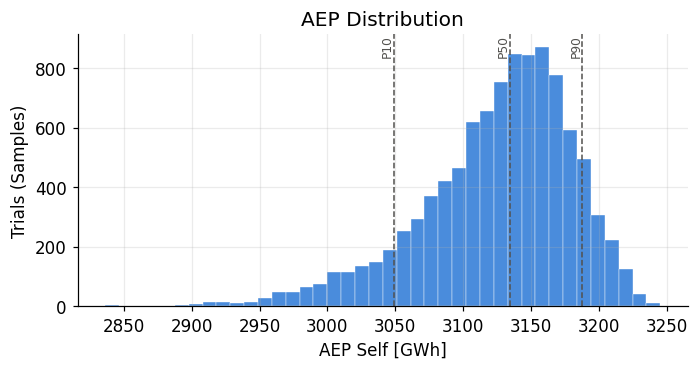

In [19]:
hist_with_percentiles(final_s1["active_aep_gwh"], COLOR_S1, "AEP Self [GWh]", "Trials (Samples)", "AEP Distribution")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Wake Loss'}, xlabel='Wake Loss [%]', ylabel='Trials (Samples)'>)

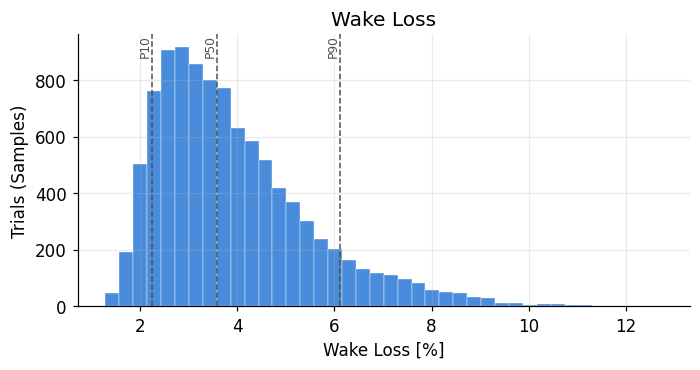

In [20]:
hist_with_percentiles(final_s1["loss_pct"], COLOR_S1, "Wake Loss [%]", "Trials (Samples)", "Wake Loss")

(<Figure size 715x198 with 1 Axes>,
 <Axes: title={'center': 'P50/P90 Bands'}, xlabel='AEP Self [GWh]'>)

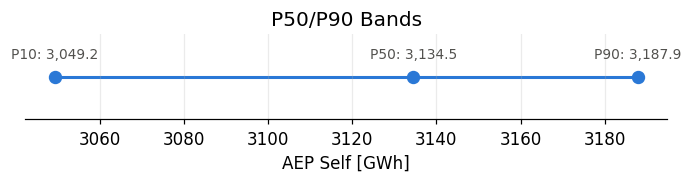

In [21]:
percentile_band_plot(final_s1["active_aep_gwh"], COLOR_S1, "AEP Self [GWh]", "P50/P90 Bands")

(<Figure size 715x198 with 1 Axes>,
 <Axes: title={'center': 'P50/P90 Bands'}, xlabel='Wake Loss [%]'>)

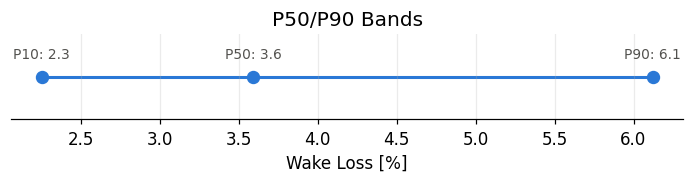

In [22]:
percentile_band_plot(final_s1["loss_pct"], COLOR_S1, "Wake Loss [%]", "P50/P90 Bands")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Loss Trajectory'}, xlabel='Simulation Year', ylabel='Wake Loss [%]'>)

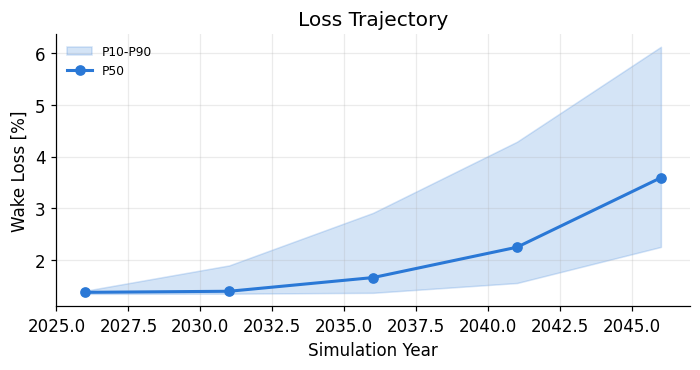

In [23]:
segment_trajectory(segments_s1, COLOR_S1, "Wake Loss [%]", "Loss Trajectory", value_col="loss_pct")

## Scenario 2 -- Fixed cluster + speculative infill expansion

### Phase 1 -- Data Audit

In [24]:
trials_s2.shape, arrivals_s2.shape, segments_s2.shape

((10000, 13), (237139, 9), (50000, 15))

In [25]:
trials_s2.isna().sum().sum(), arrivals_s2.isna().sum().sum(), segments_s2.isna().sum().sum()

(np.int64(0), np.int64(140000), np.int64(0))

In [26]:
trials_s2.trial_id.nunique(), segments_s2.trial_id.nunique()  # integrity: every trial reached the final segment

(10000, 10000)

### Input Uncertainty

In [27]:
trials_s2[['climate_rotation_deg', 'climate_speed_multiplier', 'climate_spread_multiplier']].describe()

,climate_rotation_deg,climate_speed_multiplier,climate_spread_multiplier
count,10000.000000,10000.000000,10000.000000
mean,-0.007173,0.999985,0.999829
std,1.458700,0.004755,0.025766
min,-3.935272,0.990664,0.941646
25%,-0.989038,0.996604,0.982145
50%,-0.020011,0.999940,0.999569
75%,0.990218,1.003288,1.017452
max,3.935272,1.010155,1.070733


In [28]:
final_s2['mean_density_mw_km2'].describe()

count    10000.000000
mean         4.875858
std          0.241939
min          4.129346
25%          4.709026
50%          4.867692
75%          5.038731
max          5.794355
Name: mean_density_mw_km2, dtype: float64

In [29]:
final_s2['n_speculative'].describe()

count    10000.000000
mean        10.713900
std          2.384788
min          3.000000
25%          9.000000
50%         11.000000
75%         12.000000
max         19.000000
Name: n_speculative, dtype: float64

### Correlation vs Outputs

In [30]:
predictors = ["climate_rotation_deg", "climate_speed_multiplier", "climate_spread_multiplier",
              "n_speculative", "mean_density_mw_km2", "active_mw", "n_active_turbines"]
targets = ["active_aep_gwh", "loss_pct"]

pearson_s2 = final_s2[predictors + targets].corr(method="pearson").loc[predictors, targets]
pearson_s2

,active_aep_gwh,loss_pct
climate_rotation_deg,0.045938,0.126622
climate_speed_multiplier,0.785611,-0.133825
climate_spread_multiplier,0.126502,-0.043483
n_speculative,-0.065925,0.091945
mean_density_mw_km2,0.023284,-0.023970
active_mw,-0.286209,0.482897
n_active_turbines,-0.279076,0.467659


In [31]:
spearman_s2 = final_s2[predictors + targets].corr(method="spearman").loc[predictors, targets]
spearman_s2

,active_aep_gwh,loss_pct
climate_rotation_deg,0.048307,0.132875
climate_speed_multiplier,0.801244,-0.146227
climate_spread_multiplier,0.118321,-0.045398
n_speculative,-0.063146,0.103728
mean_density_mw_km2,0.026321,-0.036236
active_mw,-0.272232,0.513094
n_active_turbines,-0.263985,0.496577


In [32]:
pearson_s2['loss_pct'].sort_values(key=abs, ascending=False)  # ranked drivers of Wake Loss

active_mw                    0.482897
n_active_turbines            0.467659
climate_speed_multiplier    -0.133825
climate_rotation_deg         0.126622
n_speculative                0.091945
climate_spread_multiplier   -0.043483
mean_density_mw_km2         -0.023970
Name: loss_pct, dtype: float64

### Phase 2 -- Exploratory Visualizations

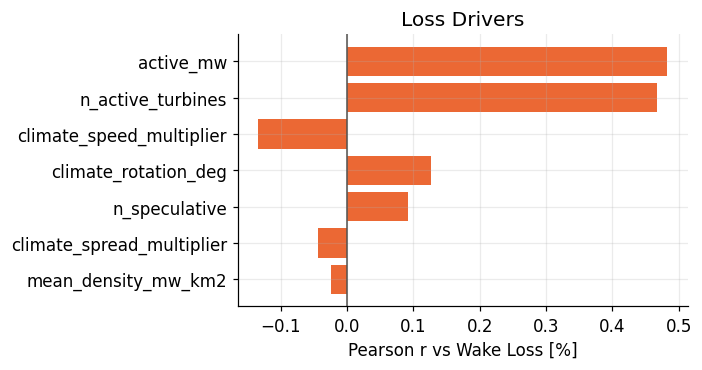

In [33]:
drivers = pearson_s2["loss_pct"].sort_values(key=abs)
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.barh(drivers.index, drivers.values, color=COLOR_S2)
ax.axvline(0, color=COLOR_NEUTRAL, linewidth=1)
ax.set_xlabel("Pearson r vs Wake Loss [%]"); ax.set_title("Loss Drivers")
fig.tight_layout()

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Turbine Density'}, xlabel='Turbine Density [MW/km²]', ylabel='Farms [count]'>)

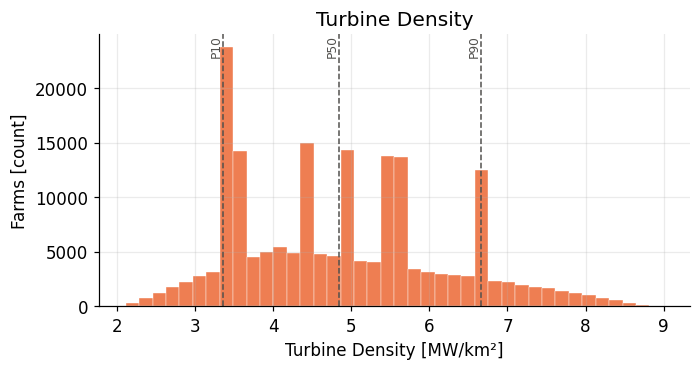

In [34]:
density = arrivals_s2["rho_target_mw_km2"].dropna()
hist_with_percentiles(density, COLOR_S2, "Turbine Density [MW/km\u00b2]", "Farms [count]", "Turbine Density")

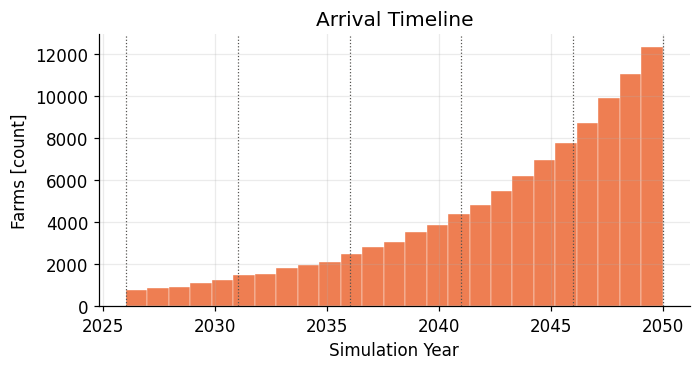

In [35]:
# only "speculative" farms draw a random arrival year -- self/real_layout/cluster_fixed are all fixed at YEAR_START
checkpoints = sorted(set(segments_s2.start_year) | set(segments_s2.end_year))
new_farm_years = arrivals_s2.loc[arrivals_s2.source == "speculative", "arrival_year"]
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(new_farm_years, bins=25, color=COLOR_S2, alpha=0.85, edgecolor="white", linewidth=0.3)
for yr in checkpoints:
    ax.axvline(yr, color=COLOR_NEUTRAL, linestyle=":", linewidth=0.8)
ax.set_xlabel("Simulation Year"); ax.set_ylabel("Farms [count]"); ax.set_title("Arrival Timeline")
fig.tight_layout()

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Turbine Scale'}, xlabel='Active Turbines [count]', ylabel='Trials (Samples)'>)

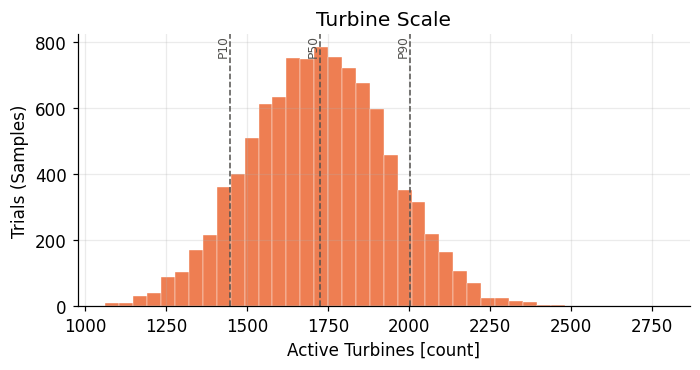

In [36]:
hist_with_percentiles(final_s2["n_active_turbines"], COLOR_S2, "Active Turbines [count]", "Trials (Samples)", "Turbine Scale")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'AEP Distribution'}, xlabel='AEP Self [GWh]', ylabel='Trials (Samples)'>)

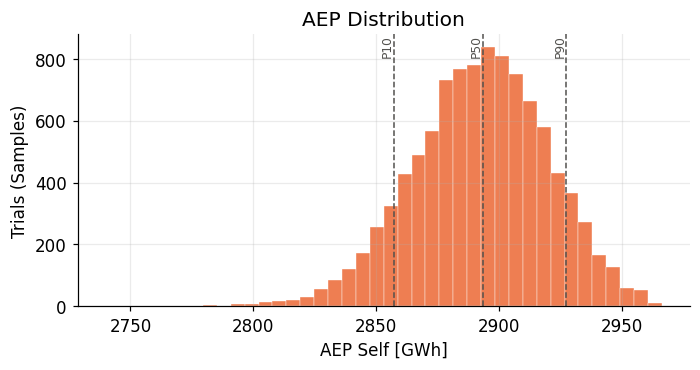

In [37]:
hist_with_percentiles(final_s2["active_aep_gwh"], COLOR_S2, "AEP Self [GWh]", "Trials (Samples)", "AEP Distribution")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Wake Loss'}, xlabel='Wake Loss [%]', ylabel='Trials (Samples)'>)

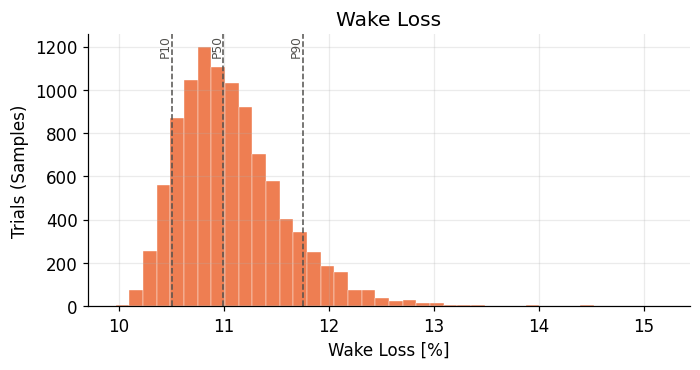

In [38]:
hist_with_percentiles(final_s2["loss_pct"], COLOR_S2, "Wake Loss [%]", "Trials (Samples)", "Wake Loss")

(<Figure size 715x198 with 1 Axes>,
 <Axes: title={'center': 'P50/P90 Bands'}, xlabel='AEP Self [GWh]'>)

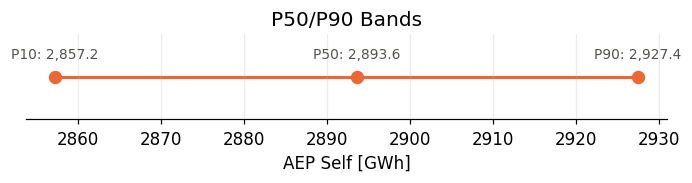

In [39]:
percentile_band_plot(final_s2["active_aep_gwh"], COLOR_S2, "AEP Self [GWh]", "P50/P90 Bands")

(<Figure size 715x198 with 1 Axes>,
 <Axes: title={'center': 'P50/P90 Bands'}, xlabel='Wake Loss [%]'>)

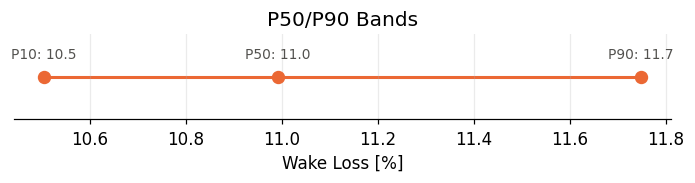

In [40]:
percentile_band_plot(final_s2["loss_pct"], COLOR_S2, "Wake Loss [%]", "P50/P90 Bands")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Loss Trajectory'}, xlabel='Simulation Year', ylabel='Wake Loss [%]'>)

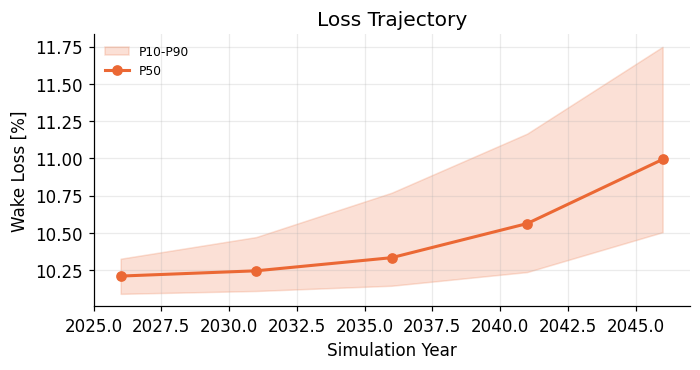

In [41]:
segment_trajectory(segments_s2, COLOR_S2, "Wake Loss [%]", "Loss Trajectory", value_col="loss_pct")